In [1]:
# Импорт необходимых библиотек
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from ultralytics import YOLO
import cv2

# Roboflow
from roboflow import Roboflow

# Инициализация Roboflow
rf = Roboflow(api_key="O8mqvaHz9G98F5Ieyy5u")

# Проверка GPU
print('CUDA available:', torch.cuda.is_available())

CUDA available: False


## Загрузка и подготовка датасетов (NumberDetection и SVHN)

In [2]:
# Скачивание датасетов с Roboflow
numberdetection_project = rf.workspace("university-of-toronto-xho85").project("numberdetection-eppfj")
svhn_project = rf.workspace("peking-uni").project("svhn-rktm0")
# Скачать NumberDetection (YOLOv8 формат)
numberdetection_dataset = numberdetection_project.version(2).download("yolov8")
numberdetection_path = numberdetection_dataset.location

# Скачать SVHN (YOLOv8 формат)
svhn_dataset = svhn_project.version(1).download("yolov8")
svhn_path = svhn_dataset.location

# Проверка наличия файлов
print('NumberDetection images:', os.listdir(os.path.join(numberdetection_path, 'train/images'))[:3])
print('SVHN images:', os.listdir(os.path.join(svhn_path, 'train/images'))[:3])

loading Roboflow workspace...
loading Roboflow project...
loading Roboflow workspace...
loading Roboflow project...
NumberDetection images: ['0_235_70_51130820_42_jpg.rf.1b3bd94f15d193d8b13de6bd49a046d3.jpg', '0_235_70_51130820_42_jpg.rf.7b618ee9fddee734c6602415d372ba42.jpg', '0_235_70_51130820_42_jpg.rf.d92a0d1c80f0f77cdaff3a3fa7c7ea6d.jpg']
SVHN images: ['10010_png.rf.688b87d62fe6d26b6be725cac0fff202.jpg', '10010_png.rf.6a677e3ca5ae858ca1ff9acaebebeace.jpg', '10010_png.rf.ecae59c9bdede5fa2567eaa8cfc0512b.jpg']


In [4]:
# Скачать дополнительный датасет для дообучения (Text Detection)
text_detection_project = rf.workspace("akshithak-0pa4q").project("text-detection-qj5wx")
text_detection_dataset = text_detection_project.version(1).download("yolov8")
text_detection_path = text_detection_dataset.location
print('Text Detection images:', os.listdir(os.path.join(text_detection_path, 'train/images'))[:3])


loading Roboflow workspace...
loading Roboflow project...
Text Detection images: ['282_jpg.rf.74855395fd9eba434daa4c58b391324a.jpg', '100_jpg.rf.072e86458094f004ab381eb018f48ea0.jpg', '102_jpg.rf.ddb412a16c99a0a0115ad65abf29ab9a.jpg']


## Предобучение модели на датасете NumberDetection

In [ ]:
# Предобучение YOLOv8 на NumberDetection с увеличенным количеством эпох
model = YOLO('yolov8n.pt')  # можно выбрать yolov8s.pt, yolov8m.pt

results = model.train(
    data=os.path.join(numberdetection_path, 'data.yaml'),
    epochs=30,  # больше эпох
    imgsz=640,
    project='numberdetection_yolo',
    name='yolov8_pretrain',
    device=0 if torch.cuda.is_available() else 'cpu',
)

# Сохранение модели
model.save('numberdetection_yolov8.pt')

NameError: name 'numberdetection_path' is not defined

## Дообучение модели на датасете SVHN

In [3]:
model = YOLO('yolov8s.pt')

results = model.train(
    data=os.path.join(svhn_path, 'data.yaml'),
    imgsz=640,
    epochs=20,patience=10,
    batch=-1,
    cos_lr=True,
    name='yolov8_sft_svhn',
    device=0 if torch.cuda.is_available() else 'cpu',
)

model.save('2_svhn_yolov8.pt')

Ultralytics 8.4.23  Python-3.13.12 torch-2.10.0+cpu CPU (AMD Ryzen 9 3950X 16-Core Processor)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=d:\projects\ITMO\cv\lab2\SVHN-1\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_sft_svhn, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=

KeyboardInterrupt: 

In [21]:
# Дообучение YOLOv8 на Text Detection с минимизацией переобучения
model = YOLO('numberdetection_yolov8.pt')  # загрузить предобученную модель

results = model.train(
    data=os.path.join(svhn_path, 'data.yaml'),
    epochs=30,
    imgsz=480,
    project='svhn_sft_yolo',
    name='yolov8_sft_svhn',
    device=0 if torch.cuda.is_available() else 'cpu',
)

# Сохранение дообученной модели
model.save('svhn_sft_yolov8.pt')

New https://pypi.org/project/ultralytics/8.4.21 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.17 🚀 Python-3.13.11 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce GTX 1660 SUPER, 5745MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/ssd/projects/ITMO/cv/lab2/SVHN-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=480, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=numberdetection_yolov8.pt, momentum=0.937, m

## Валидация

In [12]:
# Оценка на тестовой части SVHN
model = YOLO("svhn_sft_yolov8.pt")
metrics = model.val(
    data=os.path.join(svhn_path, 'data.yaml'),
    split='test',
    device=0 if torch.cuda.is_available() else 'cpu'
)

Ultralytics 8.4.23  Python-3.13.12 torch-2.10.0+cpu CPU (AMD Ryzen 9 3950X 16-Core Processor)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 99.227.9 MB/s, size: 10.9 KB)
val: Scanning D:\projects\ITMO\cv\lab2\SVHN-1\test\labels.cache... 899 images, 93 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 899/899 314.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 57/57 2.4it/s 23.7s0.4ss
                   all        899        806      0.835      0.837      0.884      0.483
Speed: 0.6ms preprocess, 22.9ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to D:\projects\ITMO\cv\runs\detect\val


In [13]:
# Оценка на тестовой части SVHN
model = YOLO("svhn_yolov8s.pt")
metrics = model.val(
    data=os.path.join(svhn_path, 'data.yaml'),
    split='test',
    device=0 if torch.cuda.is_available() else 'cpu'
)

Ultralytics 8.4.23  Python-3.13.12 torch-2.10.0+cpu CPU (AMD Ryzen 9 3950X 16-Core Processor)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 109.725.2 MB/s, size: 10.1 KB)
val: Scanning D:\projects\ITMO\cv\lab2\SVHN-1\test\labels.cache... 899 images, 93 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 899/899 377.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 57/57 1.6s/it 1:321.6sss
                   all        899        806      0.814      0.829      0.853      0.448
Speed: 1.0ms preprocess, 98.0ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to D:\projects\ITMO\cv\runs\detect\val2


## Загрузка и обработка собственных фотографий

In [29]:
# Путь к собственным фотографиям
my_photos_path = 'img/'  # папка с вашими фото
my_photos = [os.path.join(my_photos_path, fname) for fname in os.listdir(my_photos_path) if fname.endswith(('.jpg', '.png'))]
print('Фотографии для детекции:', my_photos)

Фотографии для детекции: ['img/11.jpg', 'img/12.jpg', 'img/13.jpg', 'img/7.jpg', 'img/9.jpg']



image 1/1 d:\projects\ITMO\cv\lab2\img\11.jpg: 1120x864 2 digits, 201.8ms
Speed: 6.1ms preprocess, 201.8ms inference, 0.8ms postprocess per image at shape (1, 3, 1120, 864)


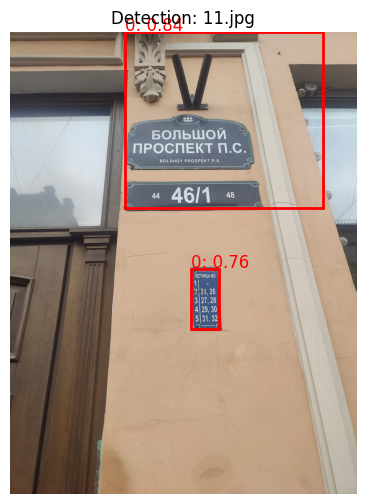


image 1/1 d:\projects\ITMO\cv\lab2\img\12.jpg: 1120x864 5 digits, 218.7ms
Speed: 6.2ms preprocess, 218.7ms inference, 1.0ms postprocess per image at shape (1, 3, 1120, 864)


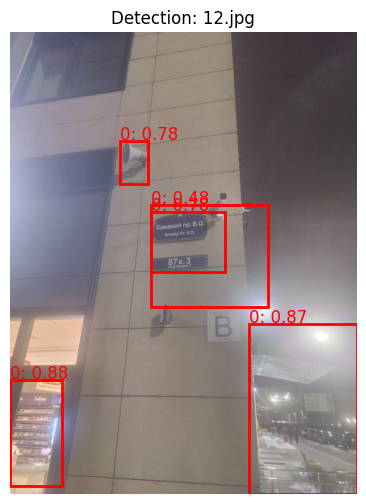


image 1/1 d:\projects\ITMO\cv\lab2\img\13.jpg: 1120x512 2 digits, 111.8ms
Speed: 5.0ms preprocess, 111.8ms inference, 0.8ms postprocess per image at shape (1, 3, 1120, 512)


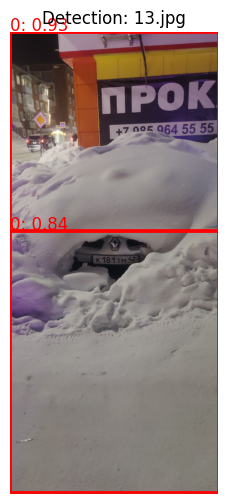


image 1/1 d:\projects\ITMO\cv\lab2\img\7.jpg: 864x1120 1 digit, 181.0ms
Speed: 4.8ms preprocess, 181.0ms inference, 0.8ms postprocess per image at shape (1, 3, 864, 1120)


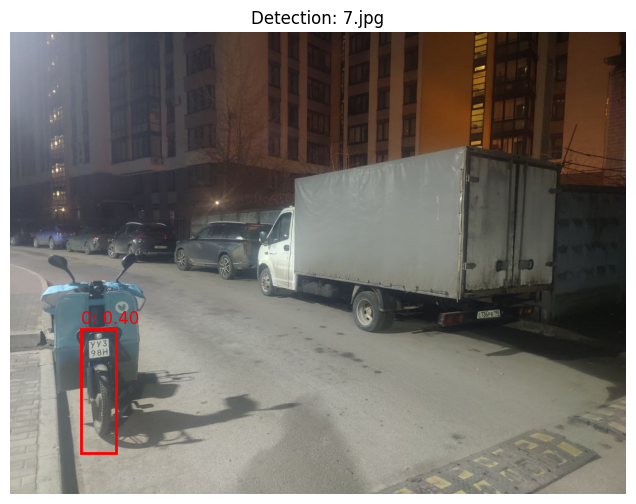


image 1/1 d:\projects\ITMO\cv\lab2\img\9.jpg: 864x1120 4 digits, 179.6ms
Speed: 5.0ms preprocess, 179.6ms inference, 0.9ms postprocess per image at shape (1, 3, 864, 1120)


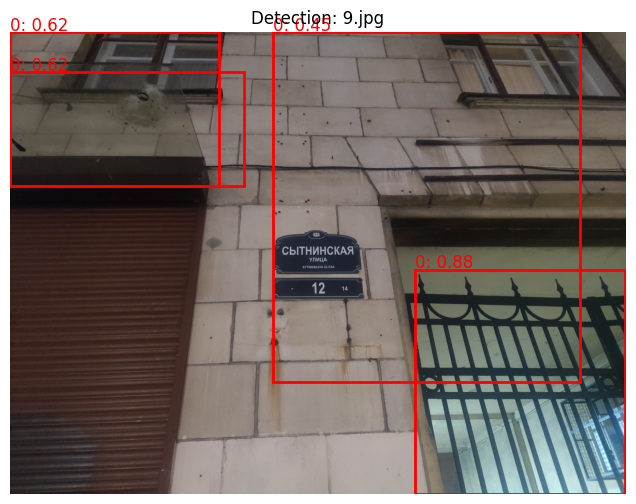

In [30]:
%matplotlib inline

# Детекция и визуализация
model = YOLO('svhn_yolov8s.pt')  # дообученная модель

for photo_path in my_photos:
    results = model(photo_path, imgsz=32*35, conf=0.395) # необходимо указать параметры для улучшения качества детекции
    img = Image.open(photo_path)
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    # Визуализация боксов
    for result in results:
        boxes = result.boxes.xyxy.cpu().numpy()  # координаты боксов
        scores = result.boxes.conf.cpu().numpy()  # уверенность
        labels = result.boxes.cls.cpu().numpy()  # классы
        for box, score, label in zip(boxes, scores, labels):
            x1, y1, x2, y2 = box.astype(int)
            plt.gca().add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                              edgecolor='red', facecolor='none', linewidth=2))
            plt.text(x1, y1 - 10, f'{int(label)}: {score:.2f}', color='red', fontsize=12)
    plt.title(f'Detection: {os.path.basename(photo_path)}')
    plt.axis('off')
    plt.show()